# Z-DNA — SNP frequency, **detected only** (Supplementary code 2 §3)

Same pipeline as `zdna_snp_frequency_notebook.ipynb` but the input is the **gofae model's detected Z-DNA** (`Z_DNA_Motif_detected.bed`, ~1152 rows) instead of all `label == 'Z_DNA_Motif'` rows from the test CSV (~31591 rows). Everything downstream (NCNR filter, 100-bp threshold, flanks, controls, locuschoice, split, intersect, IWTomics, plot) is unchanged.

R plotting cells from §3.7 are rewritten in matplotlib.

# Library

Load this before running the rest of the notebook.

In [1]:
# rpy2 is optional; R plotting cells below will be skipped if it's not installed
try:
    get_ipython().run_line_magic('load_ext', 'rpy2.ipython')
    print('rpy2 loaded')
except Exception as e:
    print('rpy2 not available (R cells will fail, which is expected for the pipeline-only run):', e)

rpy2 not available (R cells will fail, which is expected for the pipeline-only run): No module named 'rpy2'


# 3. Z-DNA (detected)

## Setup

All intermediate files are written into `results/zdna_notebook_detected_run/` and every later bash/Python cell uses relative paths inside that directory.

In [2]:
import os, sys, re, subprocess, random
from pathlib import Path
import pandas as pd
import numpy as np

BASE    = os.environ.get("SNP_AF_BASE", "/path/to/snp_af_analysis")
WORKDIR = f"{BASE}/results/zdna_notebook_detected_run"
Path(WORKDIR).mkdir(parents=True, exist_ok=True)
os.chdir(WORKDIR)

# Expose to %%bash cells
os.environ["BASE"]        = BASE
os.environ["CHROM_SIZES"] = f"{BASE}/reference/hg38.chrom.sizes"
os.environ["GAPS_BED"]    = f"{BASE}/annotations/hg38_gaps.bed"
os.environ["CODING_BED"]  = f"{BASE}/annotations/coding_regions.bed"
os.environ["REPEAT_BED"]  = f"{BASE}/annotations/repetitive_elements.bed"
os.environ["SNP_DIR"]     = f"{BASE}/snp_data/gnomad"
os.environ["PATH"]        = os.environ.get("BEDTOOLS_BIN", "") + ":" + os.environ["PATH"]
# Stage-1 (NR-Contrastive) outputs and experimental splits
# Override with environment variables; the defaults are the paths used for the paper.
PU_RESULTS      = os.environ.get("NONB_PU_RESULTS",
    "/path/to/pu_results")
EXPERIMENT_DATA = os.environ.get("NONB_EXPERIMENT_DATA",
    "/path/to/Experiment_Data")
IWTOMICS_DIR    = os.environ.get("IWTOMICS_DIR",
    "/path/to/nonb-nrcl-paper/snp_analysis/iwtomics")


random.seed(42)
np.random.seed(42)
print("cwd:", os.getcwd())
print("bedtools:", subprocess.run("which bedtools", shell=True, capture_output=True, text=True).stdout.strip())

cwd: /data/haotian/qianying/snp_af_analysis/results/zdna_notebook_detected_run
bedtools: /home/haz19024/softwares/bedtools2/bin/bedtools


## 3.1 Retrieve annotation (detected)

Load the gofae model's **detected** Z-DNA windows from `Z_DNA_Motif_detected.bed`. Columns: `chr, win_start, win_end, strand, motif_start, motif_end, sequence, p_value, q_value`. Only `motif_start` / `motif_end` are used (1-based inclusive → 0-based half-open). Z-DNA has no `spacer` field, so column 4 of the BED is just the motif length placeholder — the splitter does not use it.

In [3]:
Z_BED = f"{PU_RESULTS}/Z_DNA_Motif/Z_DNA_Motif_detected.bed"

# Detected BED columns: chr, win_start, win_end, strand, motif_start, motif_end, sequence, p_value, q_value
z_df = pd.read_csv(Z_BED, sep="\t")
print(f"detected Z-DNA rows: {len(z_df)}")

z_df = z_df.dropna(subset=["motif_start", "motif_end"]).reset_index(drop=True)
z_df["motif_start"] = z_df["motif_start"].astype(int) - 1   # 1-based inclusive -> 0-based half-open
z_df["motif_end"]   = z_df["motif_end"].astype(int)
z_df = z_df.drop_duplicates(subset=["chr","motif_start","motif_end","strand"]).reset_index(drop=True)
z_df["motif_length"] = z_df["motif_end"] - z_df["motif_start"]
print(f"after dedup: {len(z_df)}")

z_df[["chr","motif_start","motif_end","motif_length"]].to_csv(
    "ZDNA.bed", sep="\t", header=False, index=False)
print(f"wrote ZDNA.bed with {len(z_df)} rows")

detected Z-DNA rows: 1152
after dedup: 1152
wrote ZDNA.bed with 1152 rows


NCNR filter (remove overlaps with coding + repetitive) and apply the published 100-bp motif length threshold.

In [4]:
%%bash
set -euo pipefail

# Build hg38 NCNR = coding ∪ repetitive (merged) once
if [ ! -f NCNR.hg38.bed ]; then
    cat "$CODING_BED" "$REPEAT_BED" | sort -k1,1 -k2,2n | bedtools merge -i stdin > NCNR.hg38.bed
fi

bedtools intersect -a ZDNA.bed -b NCNR.hg38.bed -v > NCNRZDNA.bed
awk '{if ($3-$2<=100) print $0}' NCNRZDNA.bed > NCNR.ZDNA.100threshold.bed
bedtools sort -i NCNR.ZDNA.100threshold.bed > NCNR.ZDNA.100threshold.sorted.bed

wc -l ZDNA.bed NCNRZDNA.bed NCNR.ZDNA.100threshold.sorted.bed

 1152 ZDNA.bed
  693 NCNRZDNA.bed
  693 NCNR.ZDNA.100threshold.sorted.bed
 2538 total


## 3.2 Create Flanks

Add 2 kb flanks on each side. Output 8-col BED: chrom, flank_start, flank_end, motif_length, strand, locus_start, locus_end, spacer_field.

In [5]:
%%bash
set -euo pipefail
paste NCNR.ZDNA.100threshold.sorted.bed \
    <(bedtools slop -i NCNR.ZDNA.100threshold.sorted.bed -g "$CHROM_SIZES" -b 2000) \
  | awk 'BEGIN{OFS="\t"}{print $1, $6, $7, $3-$2, "+", $2, $3, $4}' \
  > NCNRZDNA.flanked.bed

wc -l NCNRZDNA.flanked.bed
head -2 NCNRZDNA.flanked.bed

693 NCNRZDNA.flanked.bed
chr1	1042777	1046789	12	+	1044777	1044789	12
chr1	1158567	1162577	10	+	1160567	1160577	10


## 3.3 Create Controls

Shuffle exclusion unions THREE sources so controls never fall in forbidden regions: (1) all Z-DNA motifs, (2) NCNR, (3) `hg38_gaps.bed`. Gaps matter here: leaving them out lets controls land in centromeric/telomeric N-runs and artificially depresses the control SNP baseline.

In [6]:
%%bash
set -euo pipefail

cut -f 1-3 NCNR.ZDNA.100threshold.sorted.bed > _temp_ZDNA

cat _temp_ZDNA "$GAPS_BED" NCNR.hg38.bed \
  | cut -f1-3 \
  | sort -k1,1 -k2,2n | bedtools merge -i stdin > exclude_ZDNA.bed

bedtools shuffle -i NCNR.ZDNA.100threshold.sorted.bed \
    -excl exclude_ZDNA.bed -g "$CHROM_SIZES" \
    -chrom -f 0 -noOverlapping -seed 42 > _temp_ZDNA_shuffled
bedtools sort -i _temp_ZDNA_shuffled > NCNRZDNA.shuffled.bed

paste NCNRZDNA.shuffled.bed \
    <(bedtools slop -i NCNRZDNA.shuffled.bed -g "$CHROM_SIZES" -b 2000) \
  | awk 'BEGIN{OFS="\t"}{print $1, $6, $7, $3-$2+1, "+", $2, $3, $4}' \
  > NCNRZDNA.shuffled.flanked.bed

rm -f _temp_ZDNA _temp_ZDNA_shuffled
wc -l NCNRZDNA.shuffled.flanked.bed
head -2 NCNRZDNA.shuffled.flanked.bed

693 NCNRZDNA.shuffled.flanked.bed
chr1	2252092	2256103	12	+	2254092	2254103	11
chr1	4160368	4164378	11	+	4162368	4162378	10


## 3.4 Pick non-overlapping windows

Python reimplementation of the published `Locuschoice.py`: greedy pass that, within each overlap cluster on a chromosome, keeps one random motif and drops the rest. This removes pseudo-replication from the 4 kb flanked windows.

In [7]:
def locuschoice(in_bed, out_bed, seed=42):
    rng = random.Random(seed)
    last_chrom = "chr0"
    last_end = 0
    tochoose = []
    nkept = 0
    with open(in_bed) as f_in, open(out_bed, "w") as f_out:
        for line in f_in:
            arr = line.rstrip("\n").split("\t")
            chrom = arr[0]; ws = int(arr[1]); we = int(arr[2])
            if chrom == last_chrom:
                if ws < last_end:
                    tochoose.append(arr); last_end = we
                else:
                    chosen = tochoose[rng.randint(0, len(tochoose)-1)]
                    f_out.write("\t".join(chosen) + "\n"); nkept += 1
                    tochoose = [arr]; last_end = we
            else:
                if tochoose:
                    chosen = tochoose[rng.randint(0, len(tochoose)-1)]
                    f_out.write("\t".join(chosen) + "\n"); nkept += 1
                tochoose = [arr]; last_chrom = chrom; last_end = we
        if tochoose:
            chosen = tochoose[rng.randint(0, len(tochoose)-1)]
            f_out.write("\t".join(chosen) + "\n"); nkept += 1
    print(f"{in_bed} -> {out_bed}: kept {nkept}")
    return nkept

locuschoice("NCNRZDNA.flanked.bed",          "NCNRZDNA.nooverlap.bed",          seed=42)
locuschoice("NCNRZDNA.shuffled.flanked.bed", "NCNRZDNA.shuffled.nooverlap.bed", seed=43)

NCNRZDNA.flanked.bed -> NCNRZDNA.nooverlap.bed: kept 692
NCNRZDNA.shuffled.flanked.bed -> NCNRZDNA.shuffled.nooverlap.bed: kept 691


691

## 3.5 Split Motifs and Flanks

Refactor of the published `Split_ZDNA.py` into a function. Z-DNA splits each window into **3 parts**: `LeftFlank | Locus | RightFlank` (the locus is the motif itself — no spacer/repeat partition like DR / IR / MR).

Output is 5 columns: `chrom, start, end, locus_id, part_type`. `locus_id` is a 0-indexed integer assigned sequentially.

In [8]:
def split_zdna(in_bed, out_bed):
    """Split each Z-DNA flanked window into LeftFlank | Locus | RightFlank.
    Mirrors Split_ZDNA.py (Supplementary code 2 §3.5).
    Output has 5 columns: chrom, start, end, locus_id, part_type.
    """
    loci = 0
    with open(in_bed) as fin, open(out_bed, "w") as fout:
        for line in fin:
            parts = line.rstrip("\n").split("\t")
            # 8-col flanked: chrom, f_start, f_end, length, strand, l_start, l_end, spacer
            chrom, f_start, f_end, _length, _strand, l_start, l_end = parts[:7]
            lid = loci
            loci += 1
            fout.write(f"{chrom}\t{f_start}\t{l_start}\t{lid}\tLeftFlank\n")
            fout.write(f"{chrom}\t{l_start}\t{l_end}\t{lid}\tLocus\n")
            fout.write(f"{chrom}\t{l_end}\t{f_end}\t{lid}\tRightFlank\n")
    print(f"{in_bed} -> {out_bed}: {loci} Loci")
    return loci

n_motif = split_zdna("NCNRZDNA.nooverlap.bed",          "NCNRZDNA.split.bed")
n_ctrl  = split_zdna("NCNRZDNA.shuffled.nooverlap.bed", "NCNRZDNA.shuffled.split.bed")

N_MOTIF = n_motif
N_CTRL  = n_ctrl
print(f"\nN_MOTIF={N_MOTIF}  N_CTRL={N_CTRL}")
with open("split_counts.txt", "w") as f:
    f.write(f"N_MOTIF\t{N_MOTIF}\nN_CTRL\t{N_CTRL}\n")

NCNRZDNA.nooverlap.bed -> NCNRZDNA.split.bed: 692 Loci
NCNRZDNA.shuffled.nooverlap.bed -> NCNRZDNA.shuffled.split.bed: 691 Loci

N_MOTIF=692  N_CTRL=691


## 3.6 Intersect annotations with variation datasets

Per-chromosome intersect with gnomAD (`snp_data/gnomad/chr{N}_snps.bed`). A single `bedtools intersect` against the 30 GB `all_chroms_snps.bed` would be impractical; looping per chromosome produces the same output at a fraction of the memory / time.

In [9]:
def intersect_per_chrom(bed_path, out_path):
    snp_dir = os.environ["SNP_DIR"]
    chroms = sorted(pd.read_csv(bed_path, sep="\t", header=None)[0].unique())
    total = 0
    with open(out_path, "w") as fout:
        for c in chroms:
            snp_file = f"{snp_dir}/{c}_snps.bed"
            if not os.path.exists(snp_file):
                print(f"  skip {c} (no {snp_file})"); continue
            cmd = (f'awk \'$1=="{c}"\' {bed_path} '
                   f'| bedtools intersect -wa -wb -a stdin -b {snp_file} -loj')
            res = subprocess.run(cmd, shell=True, capture_output=True, text=True)
            if res.stdout:
                fout.write(res.stdout)
                total += res.stdout.count("\n")
    print(f"{bed_path} -> {out_path}: {total} lines")
    return total

# bedtools intersect needs a sorted BED
for p in ("NCNRZDNA.split.bed", "NCNRZDNA.shuffled.split.bed"):
    subprocess.run(f"bedtools sort -i {p} > _s.bed && mv _s.bed {p}", shell=True, check=True)

intersect_per_chrom("NCNRZDNA.split.bed",          "NCNRZDNA.gnomAD.intersect")
intersect_per_chrom("NCNRZDNA.shuffled.split.bed", "NCNRZDNA.gnomAD.shuffled.intersect")

NCNRZDNA.split.bed -> NCNRZDNA.gnomAD.intersect: 723341 lines
NCNRZDNA.shuffled.split.bed -> NCNRZDNA.gnomAD.shuffled.intersect: 713527 lines


713527

Compute relative positions / fractional bins per SNP (refactor of `RelativePositions_ZDNA.py`). For Z-DNA the locus is normalized to **180 bins** regardless of actual motif length — this matches the R plot in §3.7 (`LociDf$Levels <- seq(1,180,1)`).

In [10]:
LOCUS_BINS = 180
scaledpositions_Locus = [round(i,4) for i in np.arange(1, LOCUS_BINS*2, 2.0)/(LOCUS_BINS*2)]

def relative_positions(intersect_path, out_csv):
    """Refactor of RelativePositions_ZDNA.py.
    Input: per-sub-annotation intersect with gnomAD (split.bed has 5 cols: chrom,start,end,locus_id,part_type).
    Output: CSV with scaled per-SNP position for each bin-assigned match.
    """
    colnames = ["chrom","start","end","locus_id","length",
                "snp_start","snp_end","snp_pos","snp_coord_inwindow","ref","alt"]
    rows = []
    with open(intersect_path) as f:
        for line in f:
            arr = line.rstrip("\n").split("\t")
            if len(arr) < 8:
                continue
            chrom, start, end = arr[0], int(arr[1]), int(arr[2])
            locus_id, snp_pos = arr[3], arr[4]
            length = end - start
            # -loj no-overlap: "." "-1" "-1"
            if len(arr) >= 6 and arr[5] == ".":
                rows.append([chrom,start,end,locus_id,length,"NA","NA",snp_pos,"NA","NA","NA"])
                continue
            snpstart, snpend = int(arr[6]), int(arr[7])
            ref, alt = "NA", "NA"
            if snp_pos == "LeftFlank":
                coord = -(end - snpstart)
                rows.append([chrom,start,end,locus_id,length,snpstart,snpend,snp_pos,coord,ref,alt])
            elif snp_pos == "RightFlank":
                coord = snpend - start
                rows.append([chrom,start,end,locus_id,length,snpstart,snpend,snp_pos,coord,ref,alt])
            elif snp_pos == "Locus":
                if length == 0: continue
                fs = (snpstart - start) / length
                fe = (snpend   - start) / length
                for i in scaledpositions_Locus:
                    if i >= fs and i < fe:
                        rows.append([chrom,start,end,locus_id,length,snpstart,snpend,snp_pos,i,ref,alt])

    pd.DataFrame(rows, columns=colnames).to_csv(out_csv)
    print(f"{intersect_path} -> {out_csv}: {len(rows)} rows")

relative_positions("NCNRZDNA.gnomAD.intersect",          "NCNRZDNA.gnomAD.intersect.csv")
relative_positions("NCNRZDNA.gnomAD.shuffled.intersect", "NCNRZDNA.gnomAD.shuffled.intersect.csv")

NCNRZDNA.gnomAD.intersect -> NCNRZDNA.gnomAD.intersect.csv: 770309 rows
NCNRZDNA.gnomAD.shuffled.intersect -> NCNRZDNA.gnomAD.shuffled.intersect.csv: 740698 rows


## 3.7 Plot Results (Python / matplotlib)

Replacement for the original R plot cells in §3.7. Two steps:

1. **IWTomics-style permutation test** (1000 permutations, α = 0.01, min significant run length = 5). Implemented in numpy; gives per-bin significance masks for left flank, locus (180 bins), and right flank.
2. **3-panel log-scale scatter** (upstream flank | Locus | downstream flank) with grey bands over significant runs.

In [11]:
# IWTomics-style permutation test on per-locus matrices
MAX_FLANK   = 100
LOCUS_BINS  = 180
N_PERM      = 1000
ALPHA       = 0.01

scaledposLocus = [round(i,4) for i in np.arange(1, LOCUS_BINS*2, 2.0)/(LOCUS_BINS*2)]

def _build_matrices(intersect_path, n_loci):
    left_mat   = np.zeros((n_loci, MAX_FLANK),  dtype=np.float32)
    locus_mat  = np.zeros((n_loci, LOCUS_BINS), dtype=np.float32)
    right_mat  = np.zeros((n_loci, MAX_FLANK),  dtype=np.float32)
    seen = set()
    with open(intersect_path) as fh:
        for line in fh:
            f = line.rstrip("\n").split("\t")
            if len(f) < 8: continue
            lid   = int(f[3])
            ps    = int(f[1]); pe = int(f[2])
            ptype = f[4]
            if len(f) >= 6 and f[5] == ".": continue   # no-overlap locus row
            snp_start = int(f[6])
            plen  = pe - ps
            key = (lid, ptype, snp_start)
            if key in seen: continue
            seen.add(key)
            if ptype == "LeftFlank":
                coord = -(pe - snp_start)          # −1, −2 … −2000 (only keep last 100)
                idx = coord + MAX_FLANK
                if 0 <= idx < MAX_FLANK:
                    left_mat[lid, idx] += 1
            elif ptype == "RightFlank":
                coord = snp_start - ps             # 0 .. 1999
                if 0 <= coord < MAX_FLANK:
                    right_mat[lid, coord] += 1
            elif ptype == "Locus":
                if plen == 0: continue
                fs = (snp_start     - ps) / plen
                fe = (snp_start + 1 - ps) / plen
                for i, sp in enumerate(scaledposLocus):
                    if sp >= fs and sp < fe:
                        locus_mat[lid, i] += 1
    return left_mat, locus_mat, right_mat


def iwtomics(data1, data2, n_perm=N_PERM, alpha=ALPHA, seed=42):
    """Windowed permutation test mirroring IWTomics (two-sample squared-mean-difference
    statistic, adjusted p-values via cumulative windows from length 1 to p)."""
    n1, p = data1.shape
    n2    = data2.shape[0]
    n     = n1 + n2
    all_data = np.vstack([data1, data2])
    obs_t = (data1.mean(0) - data2.mean(0)) ** 2
    perm_t = np.zeros((n_perm, p), dtype=np.float64)
    rng = np.random.default_rng(seed)
    for b in range(n_perm):
        idx = rng.permutation(n)
        m1 = all_data[idx[:n1]].mean(0)
        m2 = all_data[idx[n1:]].mean(0)
        perm_t[b] = (m1 - m2) ** 2
    unadj_p = (np.sum(perm_t >= obs_t[None, :], axis=0) + 1) / (n_perm + 1)
    obs_cum  = np.concatenate([[0], np.cumsum(obs_t)])
    perm_cum = np.hstack([np.zeros((n_perm, 1)), np.cumsum(perm_t, axis=1)])
    adj_p = unadj_p.copy()
    for k in range(2, p + 1):
        obs_win  = (obs_cum[k:]  - obs_cum[:-k])  / k
        perm_win = (perm_cum[:, k:] - perm_cum[:, :-k]) / k
        win_p = (np.sum(perm_win >= obs_win[None, :], axis=0) + 1) / (n_perm + 1)
        for j in range(len(win_p)):
            for x in range(j, j + k):
                if win_p[j] > adj_p[x]:
                    adj_p[x] = win_p[j]
    return adj_p < alpha


print("Building per-locus matrices (motif) …")
z_left, z_locus, z_right = _build_matrices("NCNRZDNA.gnomAD.intersect", N_MOTIF)
print("Building per-locus matrices (control) …")
c_left, c_locus, c_right = _build_matrices("NCNRZDNA.gnomAD.shuffled.intersect", N_CTRL)

print("Running IWTomics – left flank …")
sig_left   = iwtomics(z_left,  c_left)
print(f"  significant positions: {sig_left.sum()}/{MAX_FLANK}")
print("Running IWTomics – locus …")
sig_locus  = iwtomics(z_locus, c_locus)
print(f"  significant bins: {sig_locus.sum()}/{LOCUS_BINS}")
print("Running IWTomics – right flank …")
sig_right  = iwtomics(z_right, c_right)
print(f"  significant positions: {sig_right.sum()}/{MAX_FLANK}")

# Per-bin frequencies
left_x   = np.arange(-MAX_FLANK, 0)
right_x  = np.arange(1, MAX_FLANK + 1)
locus_x  = np.arange(1, LOCUS_BINS + 1)

left_freq        = z_left.sum(0)  / N_MOTIF
locus_freq       = z_locus.sum(0) / N_MOTIF
right_freq       = z_right.sum(0) / N_MOTIF
ctrl_left_freq   = c_left.sum(0)  / N_CTRL
ctrl_locus_freq  = c_locus.sum(0) / N_CTRL
ctrl_right_freq  = c_right.sum(0) / N_CTRL

print(f"\nflank min/max  (motif):  {left_freq.min():.4f} .. {right_freq.max():.4f}")
print(f"locus min/max (motif):  {locus_freq.min():.4f} .. {locus_freq.max():.4f}")

Building per-locus matrices (motif) …
Building per-locus matrices (control) …
Running IWTomics – left flank …
  significant positions: 0/100
Running IWTomics – locus …
  significant bins: 145/180
Running IWTomics – right flank …
  significant positions: 0/100

flank min/max  (motif):  0.1720 .. 0.2543
locus min/max (motif):  0.2312 .. 0.3786


saved zdna_snp_frequency_notebook_detected.pdf and zdna_snp_frequency_notebook_detected.png


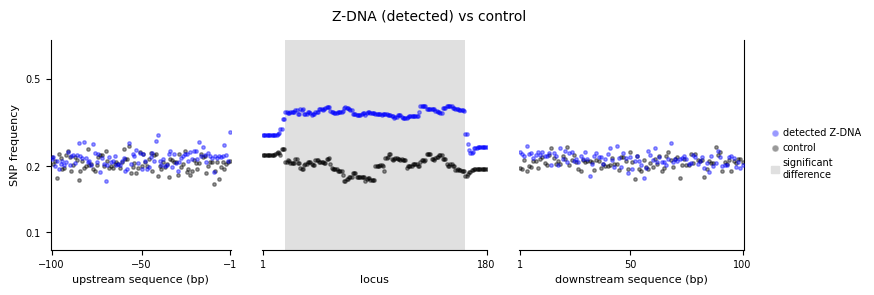

In [17]:
# 3-panel log-scale plot (matplotlib replacement of the R ggplot cell in §3.7)
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

COL_Z     = (0/255, 0/255, 255/255, 0.4)
COL_CTRL  = (0/255, 0/255, 0/255, 0.4)
COL_SIG   = (0.88, 0.88, 0.88)
PT_SIZE   = 6
MIN_SIG_RUN = 5

fig = plt.figure(figsize=(9, 3))
gs = gridspec.GridSpec(1, 3, width_ratios=[60, 75, 75], wspace=0.15,
                       left=0.08, right=0.85, top=0.88, bottom=0.18)

all_vals = np.concatenate([
    left_freq, ctrl_left_freq,
    locus_freq, ctrl_locus_freq,
    right_freq, ctrl_right_freq,
])
valid = all_vals[(all_vals > 0) & np.isfinite(all_vals)]
y_lo = valid.min() * 0.5 if len(valid) else 0.001
y_hi = valid.max() * 2.0 if len(valid) else 1.0
Y_TICKS = [t for t in [0.005, 0.01, 0.025, 0.05, 0.1, 0.2, 0.5, 1.0] if y_lo <= t <= y_hi]
Y_FMT   = ticker.FuncFormatter(lambda x, _: f"{x:g}")

def _filter_short_runs(mask, min_run=MIN_SIG_RUN):
    out = mask.copy()
    n = len(out); i = 0
    while i < n:
        if out[i]:
            j = i
            while j < n and out[j]: j += 1
            if j - i < min_run: out[i:j] = False
            i = j
        else:
            i += 1
    return out

def _add_sig_shading(ax, xs, sig_mask):
    cleaned = _filter_short_runs(sig_mask)
    if cleaned.any():
        ax.fill_between(xs, y_lo, y_hi, where=cleaned,
                        color=COL_SIG, alpha=1.0, step="mid", zorder=0, edgecolor="none")

def plot_panel(ax, x, fz, fct, sig, xlabel, show_y, is_left=False, is_right=False):
    _add_sig_shading(ax, x, sig)
    ax.scatter(x, fct, s=PT_SIZE, color=COL_CTRL, zorder=2)
    ax.scatter(x, fz,  s=PT_SIZE, color=COL_Z,    zorder=3)
    ax.set_yscale("log"); ax.set_ylim(y_lo, y_hi)
    ax.set_xlabel(xlabel, fontsize=8); ax.tick_params(labelsize=7)
    ax.spines["top"].set_visible(False)
    if show_y:
        ax.yaxis.set_major_locator(ticker.FixedLocator(Y_TICKS))
        ax.yaxis.set_major_formatter(Y_FMT)
        ax.yaxis.set_minor_locator(ticker.NullLocator())
    else:
        ax.yaxis.set_visible(False); ax.spines["left"].set_visible(False)
    if is_left:
        ax.spines["right"].set_visible(False)
    elif is_right:
        ax.spines["left"].set_visible(False)
    else:
        ax.spines["left"].set_visible(False)
        ax.spines["right"].set_visible(False)

ax0 = fig.add_subplot(gs[0])
plot_panel(ax0, left_x, left_freq, ctrl_left_freq, sig_left,
           "upstream sequence (bp)", show_y=True, is_left=True)
ax0.set_xlim(-MAX_FLANK - 0.5, -0.5); ax0.set_xticks([-100, -50, -1])
ax0.set_ylabel("SNP frequency", fontsize=8)

ax1 = fig.add_subplot(gs[1])
plot_panel(ax1, locus_x, locus_freq, ctrl_locus_freq, sig_locus,
           "locus", show_y=False)
ax1.set_xlim(0.5, LOCUS_BINS + 0.5); ax1.set_xticks([1, LOCUS_BINS])

ax2 = fig.add_subplot(gs[2])
plot_panel(ax2, right_x, right_freq, ctrl_right_freq, sig_right,
           "downstream sequence (bp)", show_y=False, is_right=True)
ax2.set_xlim(0.5, MAX_FLANK + 0.5); ax2.set_xticks([1, 50, 100])

fig.legend(
    handles=[
        Line2D([0],[0], marker="o", color="w", markerfacecolor=COL_Z,    markersize=5, label="detected Z-DNA"),
        Line2D([0],[0], marker="o", color="w", markerfacecolor=COL_CTRL, markersize=5, label="control"),
        Patch(facecolor=COL_SIG, edgecolor=COL_SIG, label="significant\ndifference"),
    ],
    fontsize=7, loc="center right", frameon=False,
    handlelength=0.8, handletextpad=0.4,
    bbox_to_anchor=(0.99, 0.5),
)
fig.suptitle("Z-DNA (detected) vs control", fontsize=10, y=0.98)

out_pdf = "zdna_snp_frequency_notebook_detected.pdf"
out_png = "zdna_snp_frequency_notebook_detected.png"
fig.savefig(out_pdf, dpi=300, bbox_inches="tight")
fig.savefig(out_png, dpi=200, bbox_inches="tight")
print(f"saved {out_pdf} and {out_png}")
plt.show()

## 3.7b Plot Results (official R IWTomics + ggplot)

Replaces the inline Python permutation test (cells 22 / 23) with the official
**IWTomics** R package (Bioconductor). Three steps:

1. **Run IWTomics in an external R session** — execute the standalone script
   `iwtomics_zdna/run_iwtomics_zdna.R` in a dedicated R environment. It reads the
   `.intersect` files produced in §3.6 directly, builds per-locus matrices,
   runs `IWTomicsTest` (two-sample mean test, B = 1000 permutations,
   α = 0.01), and saves three `.RData` files into the workdir.
2. **(Re-)run cell 22** above so that the per-bin frequency vectors
   (`left_freq`, `locus_freq`, `right_freq` and their `ctrl_*` counterparts)
   are in this kernel's namespace — the next cell writes them to CSV for R.
3. **Plot in R** with ggplot2 (mirrors the DR `§4.7` cell) — loads the
   `.RData` plus the SNP-frequency CSVs, makes the 3-panel
   `LeftFlank | Locus | RightFlank` figure, saves to PDF + PNG, and Python
   displays the PNG inline.

R is invoked from `$R_BIN`
(IWTomics + ggplot2/grid/gridExtra). No rpy2 dependency required.


### Running the R script

IWTomics runs outside the notebook, in a dedicated R environment.

1. Make sure cell §3.6 has finished — it produces the two `.intersect` files
   (`NCNRZDNA.gnomAD.intersect`, `NCNRZDNA.gnomAD.shuffled.intersect`) and
   `split_counts.txt` that IWTomics needs.

2. Open a terminal and start R from the dedicated conda env:

   ```bash
   $R_BIN
   ```

3. In the R session, run the script:

   ```text
   /path/to/snp_af_analysis/iwtomics_zdna/run_iwtomics_zdna.R
   ```

   `source()` the whole file, or run it block by block. Z-DNA has only
   three sub-parts per locus (LeftFlank | Locus | RightFlank — no
   spacer/repeat partition like DR), so the script runs IWTomics three
   times and produces three `.RData` files.

4. When the script finishes, the workdir of this notebook will contain three
   new files:

   ```
   ZDNA_motif_vs_control_IWTomics_left_0.01.RData
   ZDNA_motif_vs_control_IWTomics_locus_0.01.RData
   ZDNA_motif_vs_control_IWTomics_right_0.01.RData
   ```

5. Run the next cell below to produce the 3-panel ggplot figure (it just
   `load()`s the three `.RData` files and the frequency CSVs).


N_MOTIF=692  N_CTRL=691
building matrices (motif) …
building matrices (control) …
wrote iwt_freq_{LeftFlank,Locus,RightFlank}.csv
plotting via /home/haz19024/miniconda3/envs/r/bin/Rscript …
saved zdna_snp_frequency_notebook_iwtomics.{pdf,png}



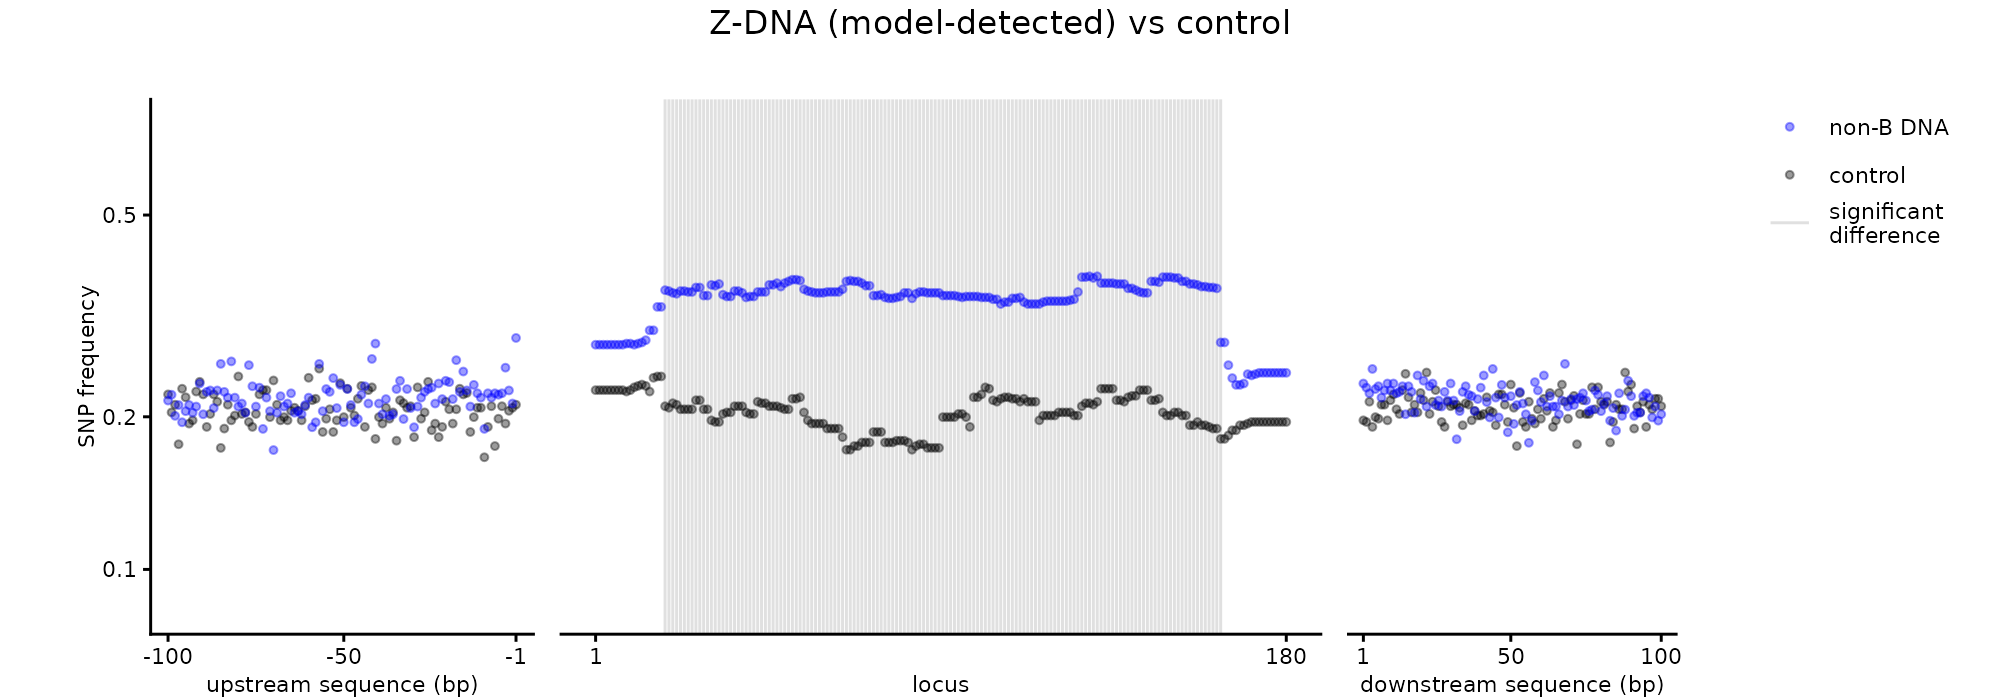

In [12]:
# R + ggplot 3-panel plot using official IWTomics .RData
# Re-builds the per-locus matrices from the .intersect files (same logic as
# cell 22, minus the slow Python permutation that R has now replaced) and
# derives per-bin SNP frequencies, then plots via R + ggplot.
import os, subprocess
from pathlib import Path
from IPython.display import Image, display
import numpy as np, pandas as pd

WORKDIR = "/path/to/snp_af_analysis/results/zdna_notebook_detected_run"
os.chdir(WORKDIR)

# parameters (must match run_iwtomics_zdna.R)
MAX_FLANK   = 100
LOCUS_BINS  = 180
scaledposLocus = [round(i, 4) for i in np.arange(1, LOCUS_BINS * 2, 2.0) / (LOCUS_BINS * 2)]

# N_MOTIF / N_CTRL from split_counts.txt
_counts = {k: int(v) for k, v in
           (line.split("\t") for line in Path("split_counts.txt").read_text().strip().splitlines())}
N_MOTIF, N_CTRL = _counts["N_MOTIF"], _counts["N_CTRL"]
print(f"N_MOTIF={N_MOTIF}  N_CTRL={N_CTRL}")

# build per-locus matrices (mirror of cell 22 _build_matrices, no perm test)
def _build_matrices(intersect_path, n_loci):
    left  = np.zeros((n_loci, MAX_FLANK),  dtype=np.float32)
    locus = np.zeros((n_loci, LOCUS_BINS), dtype=np.float32)
    right = np.zeros((n_loci, MAX_FLANK),  dtype=np.float32)
    seen = set()
    with open(intersect_path) as fh:
        for line in fh:
            f = line.rstrip("\n").split("\t")
            if len(f) < 8: continue
            if len(f) >= 6 and f[5] == ".": continue
            lid, ps, pe, ptype, snp_start = int(f[3]), int(f[1]), int(f[2]), f[4], int(f[6])
            key = (lid, ptype, snp_start)
            if key in seen: continue
            seen.add(key)
            plen = pe - ps
            if ptype == "LeftFlank":
                idx = -(pe - snp_start) + MAX_FLANK
                if 0 <= idx < MAX_FLANK: left[lid, idx] += 1
            elif ptype == "RightFlank":
                idx = snp_start - ps
                if 0 <= idx < MAX_FLANK: right[lid, idx] += 1
            elif ptype == "Locus" and plen > 0:
                fs = (snp_start     - ps) / plen
                fe = (snp_start + 1 - ps) / plen
                for i, sp in enumerate(scaledposLocus):
                    if sp >= fs and sp < fe: locus[lid, i] += 1
    return left, locus, right

print("building matrices (motif) …")
z_left, z_locus, z_right = _build_matrices("NCNRZDNA.gnomAD.intersect",          N_MOTIF)
print("building matrices (control) …")
c_left, c_locus, c_right = _build_matrices("NCNRZDNA.gnomAD.shuffled.intersect", N_CTRL)

left_freq       = z_left.sum(0)  / N_MOTIF
locus_freq      = z_locus.sum(0) / N_MOTIF
right_freq      = z_right.sum(0) / N_MOTIF
ctrl_left_freq  = c_left.sum(0)  / N_CTRL
ctrl_locus_freq = c_locus.sum(0) / N_CTRL
ctrl_right_freq = c_right.sum(0) / N_CTRL

pd.DataFrame({"LeftFlank":  left_freq,  "ctrl_LeftFlank":  ctrl_left_freq }
             ).to_csv("iwt_freq_LeftFlank.csv",  index=False)
pd.DataFrame({"Locus":      locus_freq, "ctrl_Locus":      ctrl_locus_freq}
             ).to_csv("iwt_freq_Locus.csv",      index=False)
pd.DataFrame({"RightFlank": right_freq, "ctrl_RightFlank": ctrl_right_freq}
             ).to_csv("iwt_freq_RightFlank.csv", index=False)
print("wrote iwt_freq_{LeftFlank,Locus,RightFlank}.csv")

# R + ggplot
R_BIN = os.environ.get("R_BIN", "$R_BIN")

R_PLOT = r"""
suppressMessages({
  library(ggplot2); library(grid); library(gridExtra)
})

setwd("/path/to/snp_af_analysis/results/zdna_notebook_detected_run")

# load IWTomics significance
load("ZDNA_motif_vs_control_IWTomics_left_0.01.RData")   # adj_pvalue_curve_left
load("ZDNA_motif_vs_control_IWTomics_locus_0.01.RData")  # adj_pvalue_curve_locus
load("ZDNA_motif_vs_control_IWTomics_right_0.01.RData")  # adj_pvalue_curve_right

# load per-bin frequencies
freqL <- read.csv("iwt_freq_LeftFlank.csv")    # 100 rows
freqC <- read.csv("iwt_freq_Locus.csv")        # 180 rows
freqR <- read.csv("iwt_freq_RightFlank.csv")   # 100 rows

LeftFlankDf  <- data.frame(Levels = seq(-100, -1, 1),
                           Freq   = freqL$LeftFlank,
                           C_Freq = freqL$ctrl_LeftFlank,
                           Signif = adj_pvalue_curve_left$significant)

LocusDf      <- data.frame(Levels = seq_len(nrow(freqC)),
                           Freq   = freqC$Locus,
                           C_Freq = freqC$ctrl_Locus,
                           Signif = adj_pvalue_curve_locus$significant)

RightFlankDf <- data.frame(Levels = seq(1, 100, 1),
                           Freq   = freqR$RightFlank,
                           C_Freq = freqR$ctrl_RightFlank,
                           Signif = adj_pvalue_curve_right$significant)

allv <- c(LeftFlankDf$Freq,  LeftFlankDf$C_Freq,
          LocusDf$Freq,      LocusDf$C_Freq,
          RightFlankDf$Freq, RightFlankDf$C_Freq)
allv <- allv[is.finite(allv) & allv > 0]
y_lo <- min(allv) * 0.5
y_hi <- max(allv) * 2

Y_BREAKS <- c(0.005, 0.01, 0.025, 0.05, 0.1, 0.2, 0.5, 1)
Y_BREAKS <- Y_BREAKS[Y_BREAKS >= y_lo & Y_BREAKS <= y_hi]

cols <- c("non-B DNA"               = rgb(t(col2rgb("blue")),  alpha = 100, maxColorValue = 255),
          "significant\ndifference" = "grey88",
          "control"                 = rgb(t(col2rgb("black")), alpha = 100, maxColorValue = 255))

p1 <- ggplot(LeftFlankDf, aes(x = Levels)) +
  geom_vline(xintercept = LeftFlankDf$Levels[LeftFlankDf$Signif], col = "gray88") +
  geom_point(aes(y = C_Freq, col = "control"),   size = 1) +
  geom_point(aes(y = Freq,   col = "non-B DNA"), size = 1) +
  theme_classic() +
  theme(legend.position = "none",
        axis.title  = element_text(size = 8, family = "sans"),
        axis.text.x = element_text(size = 8, family = "sans"),
        axis.text.y = element_text(size = 8, family = "sans")) +
  labs(y = "SNP frequency", x = "upstream sequence (bp)") +
  scale_colour_manual(name = "", values = cols) +
  scale_x_continuous(breaks = c(-100, -50, -1), limits = c(-100, -1)) +
  theme(plot.margin = unit(c(20, 5, 1, 1), "pt")) +
  scale_y_continuous(trans = "log", limits = c(y_lo, y_hi), breaks = Y_BREAKS)

p2 <- ggplot(LocusDf, aes(x = Levels)) +
  geom_vline(xintercept = LocusDf$Levels[LocusDf$Signif], col = "gray88") +
  geom_point(aes(y = C_Freq, col = "control"),   size = 1) +
  geom_point(aes(y = Freq,   col = "non-B DNA"), size = 1) +
  theme_classic() +
  theme(legend.position = "none",
        axis.text.x  = element_text(size = 8, family = "sans"),
        axis.title.x = element_text(size = 8, family = "sans"),
        axis.title.y = element_blank(),
        axis.text.y  = element_blank(),
        axis.ticks.y = element_blank(),
        axis.line.y  = element_blank()) +
  labs(x = "locus") +
  scale_colour_manual(name = "", values = cols) +
  scale_x_continuous(breaks = c(1, nrow(LocusDf)), limits = c(1, nrow(LocusDf))) +
  theme(plot.margin = unit(c(20, 5, 1, 5), "pt")) +
  scale_y_continuous(trans = "log", limits = c(y_lo, y_hi), breaks = Y_BREAKS)

p3 <- ggplot(RightFlankDf, aes(x = Levels)) +
  geom_line(aes(x = 0, y = 0, colour = "significant\ndifference")) +
  geom_vline(xintercept = RightFlankDf$Levels[RightFlankDf$Signif], col = "gray88") +
  geom_point(aes(y = C_Freq, col = "control"),   size = 1) +
  geom_point(aes(y = Freq,   col = "non-B DNA"), size = 1) +
  theme_classic() +
  theme(axis.title.y = element_blank(),
        axis.text.y  = element_blank(),
        axis.ticks.y = element_blank(),
        axis.line.y  = element_blank(),
        axis.text.x  = element_text(size = 8, family = "sans"),
        axis.title.x = element_text(size = 8, family = "sans"),
        legend.text  = element_text(size = 8, family = "sans"),
        legend.position      = c(1.55, 0.90),
        legend.background     = element_rect(fill = "white", colour = NA)) +
  labs(x = "downstream sequence (bp)") +
  scale_colour_manual(name = "", values = cols,
                      breaks = c("non-B DNA", "control", "significant\ndifference")) +
  scale_x_continuous(breaks = c(1, 50, 100), limits = c(1, 100)) +
  theme(plot.margin = unit(c(20, 90, 1, 5), "pt")) +
  scale_y_continuous(trans = "log", limits = c(y_lo, y_hi), breaks = Y_BREAKS) +
  guides(shape = guide_legend(order = 3))

g <- arrangeGrob(p1, p2, p3, ncol = 3,
                 widths = unit(c(60, 100, 75), c("mm", "mm", "mm")),
                 top = textGrob("Z-DNA (model-detected) vs control",
                                gp = gpar(fontsize = 12, family = "sans")))

ggsave("zdna_snp_frequency_notebook_iwtomics.pdf", g, width = 10, height = 3.5, dpi = 300, bg='white')
ggsave("zdna_snp_frequency_notebook_iwtomics.png", g, width = 10, height = 3.5, dpi = 200, bg='white')
cat("saved zdna_snp_frequency_notebook_iwtomics.{pdf,png}\n")
"""

Path("plot_zdna_iwtomics.R").write_text(R_PLOT)
print(f"plotting via {R_BIN} …")
proc = subprocess.run([R_BIN, "--vanilla", "plot_zdna_iwtomics.R"],
                      capture_output=True, text=True)
print(proc.stdout)
if proc.returncode != 0:
    print("STDERR:\n", proc.stderr)
    raise RuntimeError(f"Rscript plot failed (code {proc.returncode})")

display(Image("zdna_snp_frequency_notebook_iwtomics.png"))


## 3.8 Permuting tests and controls (legacy reference, not used by the matplotlib path above)

Generates the permuted-null CSVs (1000 permutations) that originally fed the R IWTomics implementation. The matplotlib pipeline in §3.7 above already does its own permutation test in numpy, so this cell is kept only as a reference to the published `Permuting.py`.

Args for `Permuting.py` are: `<motif_csv> <ctrl_csv> N_motif N_motif_spacer N_ctrl N_ctrl_spacer <out_motif> <out_ctrl>` — for Z-DNA the spacer columns are unused so passing the locus count for both is fine.

In [ ]:
#Permuting.py

import sys
import random
from collections import Counter
import pandas as pd

def extract_pos(infile): # this extract all snps in different \
                        #sections of a same non-B DNA loci
    infile.readline() #skip first line
    loci = {}
    last_pos = ''
    for line in infile:
        array = line.strip().split(',')

        if len(array) == 12: # G4s have one more columns, snp_pos is the section, snp_distance is the scaled position
            chrom, start, end, snp_pos, snpdistance = array[1], array[2], array[3], array[8], array[9]
        elif len(array) == 11:
            chrom, start, end, snp_pos, snpdistance = array[1], array[2], array[3], array[7], array[8]            
        else:
            print('Array length error')

        #next we group all SNPs that came from the same non-B locus
        if snp_pos == 'flank1' or snp_pos == 'LeftFlank':
            if last_pos == 'flank2' or last_pos == 'RightFlank':#should always be the start of a locus but the first one
                locus = chrom+"|"+start+"|"+end
                loci[locus] = locus_array

                locus_start = start
                locus_array = []
                if snpdistance!= 'NA':
                    locus_array.append(snp_pos+'|'+snpdistance)

            elif last_pos == '':#first start
                locus_start = start
                locus_array = []
                if snpdistance!= 'NA':
                    locus_array.append(snp_pos+'|'+snpdistance)  

            else:
                if snpdistance!= 'NA':
                    locus_array.append(snp_pos+'|'+snpdistance)
        else:
            if snpdistance!= 'NA':
                locus_array.append(snp_pos+'|'+snpdistance)
            locus_end = end

        last_pos = snp_pos

    locus = chrom+"|"+start+"|"+end #last iteration
    loci[locus] = locus_array #last iteration
    return(loci)

def count_freqs(loci, denominator, optional_denominator):

    subparts = {}
    for locus in loci:


        for snp in locus:        
            snp_pos, snp_coord = snp.split('|')
            if snp_pos in subparts:
                subparts[snp_pos].append(snp_coord)
            else:
                subparts[snp_pos] = [snp_coord]

    rows = []
    for subpart in subparts:
        freq = Counter(subparts[subpart])
        for value in freq.items():
            snp_coord, count = value
            if subpart == 'Spacer':
                freq = float(count) / optional_denominator
            else:
                freq = float(count) / denominator

            rows.append([subpart, float(snp_coord), freq])

    return(rows)


colnames = ['subpart','snp_coord','freq']

pool = []

infile = open(sys.argv[1], 'rt')
loci_dict = extract_pos(infile)
loci = []


for locus in loci_dict:
    pool.append(loci_dict[locus])
    loci.append(loci_dict[locus])

first_col = count_freqs(loci, int(sys.argv[3]), int(sys.argv[4]))
loci_df = pd.DataFrame(data=first_col, columns=colnames)


infile = open(sys.argv[2], 'rt')
ctrl_loci_dict = extract_pos(infile)
ctrl_loci = []

for locus in ctrl_loci_dict:
    pool.append(ctrl_loci_dict[locus])
    ctrl_loci.append(ctrl_loci_dict[locus])

first_ctrl_col = count_freqs(ctrl_loci, int(sys.argv[5]), int(sys.argv[6]))    
ctrl_loci_df = pd.DataFrame(data=first_ctrl_col, columns=colnames)



permutation = 1
while permutation <= 1000:
    colnames = ['subpart','snp_coord', 'freq '+str(permutation)]

    random.shuffle(pool)
    random_loci = pool[:int(sys.argv[3])]
    random_ctrl_loci = pool[int(sys.argv[3]):]


    new_col = count_freqs(random_loci, int(sys.argv[3]), int(sys.argv[4]))
    new_ctrl_col = count_freqs(random_ctrl_loci, int(sys.argv[5]), int(sys.argv[6]))
    new_df = pd.DataFrame(data=new_col, columns=colnames)
    new_ctrl_df = pd.DataFrame(data=new_ctrl_col, columns=colnames)

    loci_df = pd.merge(loci_df, new_df, how='outer', on=['subpart','snp_coord'])
    ctrl_loci_df = pd.merge(ctrl_loci_df, new_ctrl_df, how='outer', on=['subpart','snp_coord'])

    permutation += 1



pd.DataFrame.to_csv(loci_df, sys.argv[7])  
pd.DataFrame.to_csv(ctrl_loci_df, sys.argv[8])

```
# Fill in the four counts from the split-step printout for our data, then run:
python Permuting.py \
    NCNRZDNA.gnomAD.intersect.csv \
    NCNRZDNA.gnomAD.shuffled.intersect.csv \
    <N_motif> <N_motif> <N_ctrl> <N_ctrl> \
    NCNRZDNA.gnomAD.permuted \
    NCNRZDNA.gnomAD.shuffled.permuted
```

## 3.9 Frequencies of substitution types

In [ ]:
%%bash
# List SNPs at positions of interest and adjust coordinates for trinucleotide context
awk '{if ($5=="+") print $0 }' NCNRZDNA.nooverlap.bed | awk 'BEGIN {OFS="\t"} {print $1, $6-2, $6+1}' | awk '{if ($2>0) print $0}'> NCNRZDNA.trinucl.left.bed
awk '{if ($5=="+") print $0 }' NCNRZDNA.shuffled.nooverlap.bed | awk 'BEGIN {OFS="\t"} {print $1, $6-2, $6+1}' | awk '{if ($2>0) print $0}'> NCNRZDNA.shuffled.trinucl.left.bed

awk '{if ($5=="+") print $0 }' NCNRZDNA.nooverlap.bed |awk 'BEGIN {OFS="\t"} {print $1, $7-1, $7+2}' > NCNRZDNA.trinucl.right.bed
awk '{if ($5=="+") print $0 }' NCNRZDNA.shuffled.nooverlap.bed |awk 'BEGIN {OFS="\t"} {print $1, $7-1, $7+2}' > NCNRZDNA.shuffled.trinucl.right.bed

```
bedtools getfasta -fi hg38.fa -bed NCNRZDNA.trinucl.left.bed > NCNRZDNA.trinucl.left.fa
bedtools getfasta -fi hg38.fa -bed NCNRZDNA.shuffled.trinucl.left.bed > NCNRZDNA.shuffled.trinucl.left.fa
bedtools getfasta -fi hg38.fa -bed NCNRZDNA.trinucl.right.bed > NCNRZDNA.trinucl.right.fa
bedtools getfasta -fi hg38.fa -bed NCNRZDNA.shuffled.trinucl.right.bed > NCNRZDNA.shuffled.trinucl.right.fa
```

## 3.10 Add undetected Z-DNA signal

Build the **undetected** Z-DNA pool = all `label == 'Z_DNA_Motif'` rows from the test CSV minus the gofae-detected rows. Run the same pipeline (NCNR filter → 100-bp threshold → flanks → locuschoice → split → gnomAD intersect → per-locus matrix). The detected/control matrices already in memory (cell §3.7) are reused as-is.

The new plot overlays three series — **detected (blue)**, **undetected (orange)**, **control (black)** — and the significance shading is the IWTomics test of **detected vs undetected** (not detected vs control). Z-DNA has only three sub-parts per locus (LeftFlank | Locus | RightFlank — no spacer/repeat partition like IR/DR).

In [13]:
# 3.10.1 Build the undetected Z-DNA pool = all-test Z-DNA minus detected
TEST_CSV = f"{EXPERIMENT_DATA}/Z_DNA_Motif_test.csv"
Z_BED    = f"{PU_RESULTS}/Z_DNA_Motif/Z_DNA_Motif_detected.bed"

# All-test Z-DNA (label == 'Z_DNA_Motif'), still 1-based for matching
df_all = pd.read_csv(TEST_CSV, usecols=["chr","strand","motif_start","motif_end","label"])
df_all = df_all[df_all["label"] == "Z_DNA_Motif"].copy()
df_all = df_all.dropna(subset=["motif_start","motif_end"]).reset_index(drop=True)
df_all["motif_start"] = df_all["motif_start"].astype(int)
df_all["motif_end"]   = df_all["motif_end"].astype(int)
df_all = df_all.drop_duplicates(subset=["chr","motif_start","motif_end","strand"]).reset_index(drop=True)

# Detected coords (1-based) for the set difference
df_det_min = pd.read_csv(Z_BED, sep="\t", usecols=["chr","strand","motif_start","motif_end"])
df_det_min["motif_start"] = df_det_min["motif_start"].astype(int)
df_det_min["motif_end"]   = df_det_min["motif_end"].astype(int)
df_det_min = df_det_min.drop_duplicates().assign(_is_det=True)

df_undet = df_all.merge(df_det_min, on=["chr","motif_start","motif_end","strand"], how="left")
df_undet = df_undet[df_undet["_is_det"].isna()].drop(columns=["_is_det"]).reset_index(drop=True)
print(f"all-test Z-DNA: {len(df_all)}, detected: {len(df_det_min)}, undetected: {len(df_undet)}")

# 1-based inclusive -> 0-based half-open (mirror of cell §3.1: only motif_start needs -1)
df_undet["motif_start"]  = df_undet["motif_start"] - 1
df_undet["motif_length"] = df_undet["motif_end"] - df_undet["motif_start"]
df_undet[["chr","motif_start","motif_end","motif_length"]].to_csv(
    "ZDNA.undet.bed", sep="\t", header=False, index=False)
print(f"wrote ZDNA.undet.bed with {len(df_undet)} rows")

all-test Z-DNA: 31591, detected: 1152, undetected: 30439
wrote ZDNA.undet.bed with 30439 rows


In [14]:
%%bash
set -euo pipefail

# NCNR filter (undetected) -- relies on NCNR.hg38.bed already built in cell §3.1
bedtools intersect -a ZDNA.undet.bed -b NCNR.hg38.bed -v > NCNRZDNA.undet.bed
awk '{if ($3-$2<=100) print $0}' NCNRZDNA.undet.bed > NCNR.ZDNA.undet.100threshold.bed
bedtools sort -i NCNR.ZDNA.undet.100threshold.bed > NCNR.ZDNA.undet.100threshold.sorted.bed

# 2 kb flanks (same 8-col format as the motif flanked.bed in cell §3.2)
paste NCNR.ZDNA.undet.100threshold.sorted.bed \
    <(bedtools slop -i NCNR.ZDNA.undet.100threshold.sorted.bed -g "$CHROM_SIZES" -b 2000) \
  | awk 'BEGIN{OFS="\t"}{print $1, $6, $7, $3-$2, "+", $2, $3, $4}' \
  > NCNRZDNA.undet.flanked.bed

wc -l ZDNA.undet.bed NCNRZDNA.undet.bed NCNR.ZDNA.undet.100threshold.sorted.bed NCNRZDNA.undet.flanked.bed
head -2 NCNRZDNA.undet.flanked.bed

  30439 ZDNA.undet.bed
  18458 NCNRZDNA.undet.bed
  18458 NCNR.ZDNA.undet.100threshold.sorted.bed
  18458 NCNRZDNA.undet.flanked.bed
  85813 total
chr1	644804	648814	10	+	646804	646814	10
chr1	795588	799598	10	+	797588	797598	10


In [15]:
# 3.10.3 locuschoice + split_zdna + per-chrom gnomAD intersect (undetected)
locuschoice("NCNRZDNA.undet.flanked.bed", "NCNRZDNA.undet.nooverlap.bed", seed=44)

N_UNDET = split_zdna("NCNRZDNA.undet.nooverlap.bed", "NCNRZDNA.undet.split.bed")
print(f"\nN_UNDET={N_UNDET}")

subprocess.run(
    "bedtools sort -i NCNRZDNA.undet.split.bed > _s.bed && mv _s.bed NCNRZDNA.undet.split.bed",
    shell=True, check=True,
)
intersect_per_chrom("NCNRZDNA.undet.split.bed", "NCNRZDNA.gnomAD.undet.intersect")

NCNRZDNA.undet.flanked.bed -> NCNRZDNA.undet.nooverlap.bed: kept 17387
NCNRZDNA.undet.nooverlap.bed -> NCNRZDNA.undet.split.bed: 17387 Loci

N_UNDET=17387
NCNRZDNA.undet.split.bed -> NCNRZDNA.gnomAD.undet.intersect: 18251215 lines


18251215

Building per-locus matrices (undetected) …
IWTomics – left flank (detected vs undetected) …
  significant positions: 0/100
IWTomics – locus (detected vs undetected) …
  significant bins: 0/180
IWTomics – right flank (detected vs undetected) …
  significant positions: 0/100
saved zdna_snp_frequency_notebook_detected_with_undet.pdf and zdna_snp_frequency_notebook_detected_with_undet.png


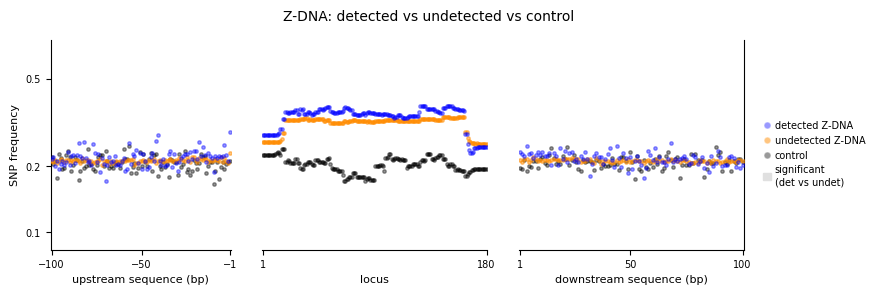

In [18]:
# 3.10.4 Plot -- detected (blue) + undetected (orange) + control (black)
# Significance shading = IWTomics(detected vs undetected). Reuses helpers/colors
# (COL_Z, COL_CTRL, COL_SIG, PT_SIZE, _filter_short_runs) defined in cell §3.7.
COL_UND = (255/255, 140/255, 0/255, 0.5)   # orange

print("Building per-locus matrices (undetected) …")
u_left, u_locus, u_right = _build_matrices("NCNRZDNA.gnomAD.undet.intersect", N_UNDET)

print("IWTomics – left flank (detected vs undetected) …")
sig_dvu_left  = iwtomics(z_left,  u_left)
print(f"  significant positions: {sig_dvu_left.sum()}/{MAX_FLANK}")
print("IWTomics – locus (detected vs undetected) …")
sig_dvu_locus = iwtomics(z_locus, u_locus)
print(f"  significant bins: {sig_dvu_locus.sum()}/{LOCUS_BINS}")
print("IWTomics – right flank (detected vs undetected) …")
sig_dvu_right = iwtomics(z_right, u_right)
print(f"  significant positions: {sig_dvu_right.sum()}/{MAX_FLANK}")

undet_left_freq  = u_left.sum(0)  / N_UNDET
undet_locus_freq = u_locus.sum(0) / N_UNDET
undet_right_freq = u_right.sum(0) / N_UNDET

fig = plt.figure(figsize=(9, 3))
gs = gridspec.GridSpec(1, 3, width_ratios=[60, 75, 75], wspace=0.15,
                       left=0.08, right=0.85, top=0.88, bottom=0.18)

all_vals2 = np.concatenate([
    left_freq, ctrl_left_freq, undet_left_freq,
    locus_freq, ctrl_locus_freq, undet_locus_freq,
    right_freq, ctrl_right_freq, undet_right_freq,
])
valid2 = all_vals2[(all_vals2 > 0) & np.isfinite(all_vals2)]
y_lo2 = valid2.min() * 0.5 if len(valid2) else 0.001
y_hi2 = valid2.max() * 2.0 if len(valid2) else 1.0
Y_TICKS2 = [t for t in [0.005, 0.01, 0.025, 0.05, 0.1, 0.2, 0.5, 1.0] if y_lo2 <= t <= y_hi2]
Y_FMT2   = ticker.FuncFormatter(lambda x, _: f"{x:g}")

def _add_sig_shading2(ax, xs, sig_mask):
    cleaned = _filter_short_runs(sig_mask)
    if cleaned.any():
        ax.fill_between(xs, y_lo2, y_hi2, where=cleaned,
                        color=COL_SIG, alpha=1.0, step="mid", zorder=0, edgecolor="none")

def plot_panel3(ax, x, fz, fct, fu, sig, xlabel, show_y, is_left=False, is_right=False):
    _add_sig_shading2(ax, x, sig)
    ax.scatter(x, fct, s=PT_SIZE, color=COL_CTRL, zorder=2)
    ax.scatter(x, fu,  s=PT_SIZE, color=COL_UND,  zorder=3)
    ax.scatter(x, fz,  s=PT_SIZE, color=COL_Z,    zorder=4)
    ax.set_yscale("log"); ax.set_ylim(y_lo2, y_hi2)
    ax.set_xlabel(xlabel, fontsize=8); ax.tick_params(labelsize=7)
    ax.spines["top"].set_visible(False)
    if show_y:
        ax.yaxis.set_major_locator(ticker.FixedLocator(Y_TICKS2))
        ax.yaxis.set_major_formatter(Y_FMT2)
        ax.yaxis.set_minor_locator(ticker.NullLocator())
    else:
        ax.yaxis.set_visible(False); ax.spines["left"].set_visible(False)
    if is_left:    ax.spines["right"].set_visible(False)
    elif is_right: ax.spines["left"].set_visible(False)
    else:          ax.spines["left"].set_visible(False); ax.spines["right"].set_visible(False)

ax0 = fig.add_subplot(gs[0])
plot_panel3(ax0, left_x, left_freq, ctrl_left_freq, undet_left_freq, sig_dvu_left,
            "upstream sequence (bp)", show_y=True, is_left=True)
ax0.set_xlim(-MAX_FLANK - 0.5, -0.5); ax0.set_xticks([-100, -50, -1])
ax0.set_ylabel("SNP frequency", fontsize=8)

ax1 = fig.add_subplot(gs[1])
plot_panel3(ax1, locus_x, locus_freq, ctrl_locus_freq, undet_locus_freq, sig_dvu_locus,
            "locus", show_y=False)
ax1.set_xlim(0.5, LOCUS_BINS + 0.5); ax1.set_xticks([1, LOCUS_BINS])

ax2 = fig.add_subplot(gs[2])
plot_panel3(ax2, right_x, right_freq, ctrl_right_freq, undet_right_freq, sig_dvu_right,
            "downstream sequence (bp)", show_y=False, is_right=True)
ax2.set_xlim(0.5, MAX_FLANK + 0.5); ax2.set_xticks([1, 50, 100])

fig.legend(
    handles=[
        Line2D([0],[0], marker="o", color="w", markerfacecolor=COL_Z,    markersize=5, label="detected Z-DNA"),
        Line2D([0],[0], marker="o", color="w", markerfacecolor=COL_UND,  markersize=5, label="undetected Z-DNA"),
        Line2D([0],[0], marker="o", color="w", markerfacecolor=COL_CTRL, markersize=5, label="control"),
        Patch(facecolor=COL_SIG, edgecolor=COL_SIG, label="significant\n(det vs undet)"),
    ],
    fontsize=7, loc="center right", frameon=False,
    handlelength=0.8, handletextpad=0.4,
    bbox_to_anchor=(0.995, 0.5),
)
fig.suptitle("Z-DNA: detected vs undetected vs control", fontsize=10, y=0.98)

out_pdf2 = "zdna_snp_frequency_notebook_detected_with_undet.pdf"
out_png2 = "zdna_snp_frequency_notebook_detected_with_undet.png"
fig.savefig(out_pdf2, dpi=300, bbox_inches="tight")
fig.savefig(out_png2, dpi=200, bbox_inches="tight")
print(f"saved {out_pdf2} and {out_png2}")
plt.show()

## 3.10b Plot detected / undetected / control (official R IWTomics + ggplot)

Re-run the IWTomics significance for **detected vs undetected** using the **official IWTomics R Bioconductor package** (Pini & Vantini 2017, IWTomics 1.36) instead of the Python permutation, then re-plot the 3-panel figure (detected / undetected / control) using `ggplot2`. Blue (detected) and black (control) per-bin frequencies are unchanged from section 3.7b; orange (undetected) is added; gray shading is now the official R IWTomics adjusted p-value < 0.01 mask (det vs undet), computed once per sub-part. The legend sits **outside** the panels on the right.

### Running the R script

A standalone R script is saved at `iwtomics_zdna/run_iwtomics_zdna_dvu.R`. It reads `NCNRZDNA.gnomAD.intersect` (detected) and `NCNRZDNA.gnomAD.undet.intersect` (undetected) directly, builds per-locus matrices for the 3 sub-parts (LeftFlank | Locus | RightFlank), and runs `IWTomicsTest(..., statistics="mean", B=1000)` once per sub-part. Outputs:

* `ZDNA_detected_vs_undetected_IWTomics_left_0.01.RData`  -> `adj_pvalue_curve_left`
* `ZDNA_detected_vs_undetected_IWTomics_locus_0.01.RData` -> `adj_pvalue_curve_locus`
* `ZDNA_detected_vs_undetected_IWTomics_right_0.01.RData` -> `adj_pvalue_curve_right`

Run it (after cell §3.10.3 has produced `NCNRZDNA.gnomAD.undet.intersect`):

```bash
$R_BIN --vanilla \
  /path/to/snp_af_analysis/iwtomics_zdna/run_iwtomics_zdna_dvu.R
```

`run_iwtomics_zdna_dvu.R` appends `N_UNDET` to `split_counts.txt` on the first run so the plotting cell below can pick it up. Once the three `.RData` files are on disk, run the plot cell below.

N_DET=692  N_UNDET=17387  N_CTRL=691
building matrices (detected) ...
building matrices (control) ...
building matrices (undetected) ...
wrote iwt_freq_dvu_{LeftFlank,RightFlank,Locus}.csv
plotting via /home/haz19024/miniconda3/envs/r/bin/Rscript ...
saved zdna_snp_frequency_notebook_dvu_iwtomics.{pdf,png}



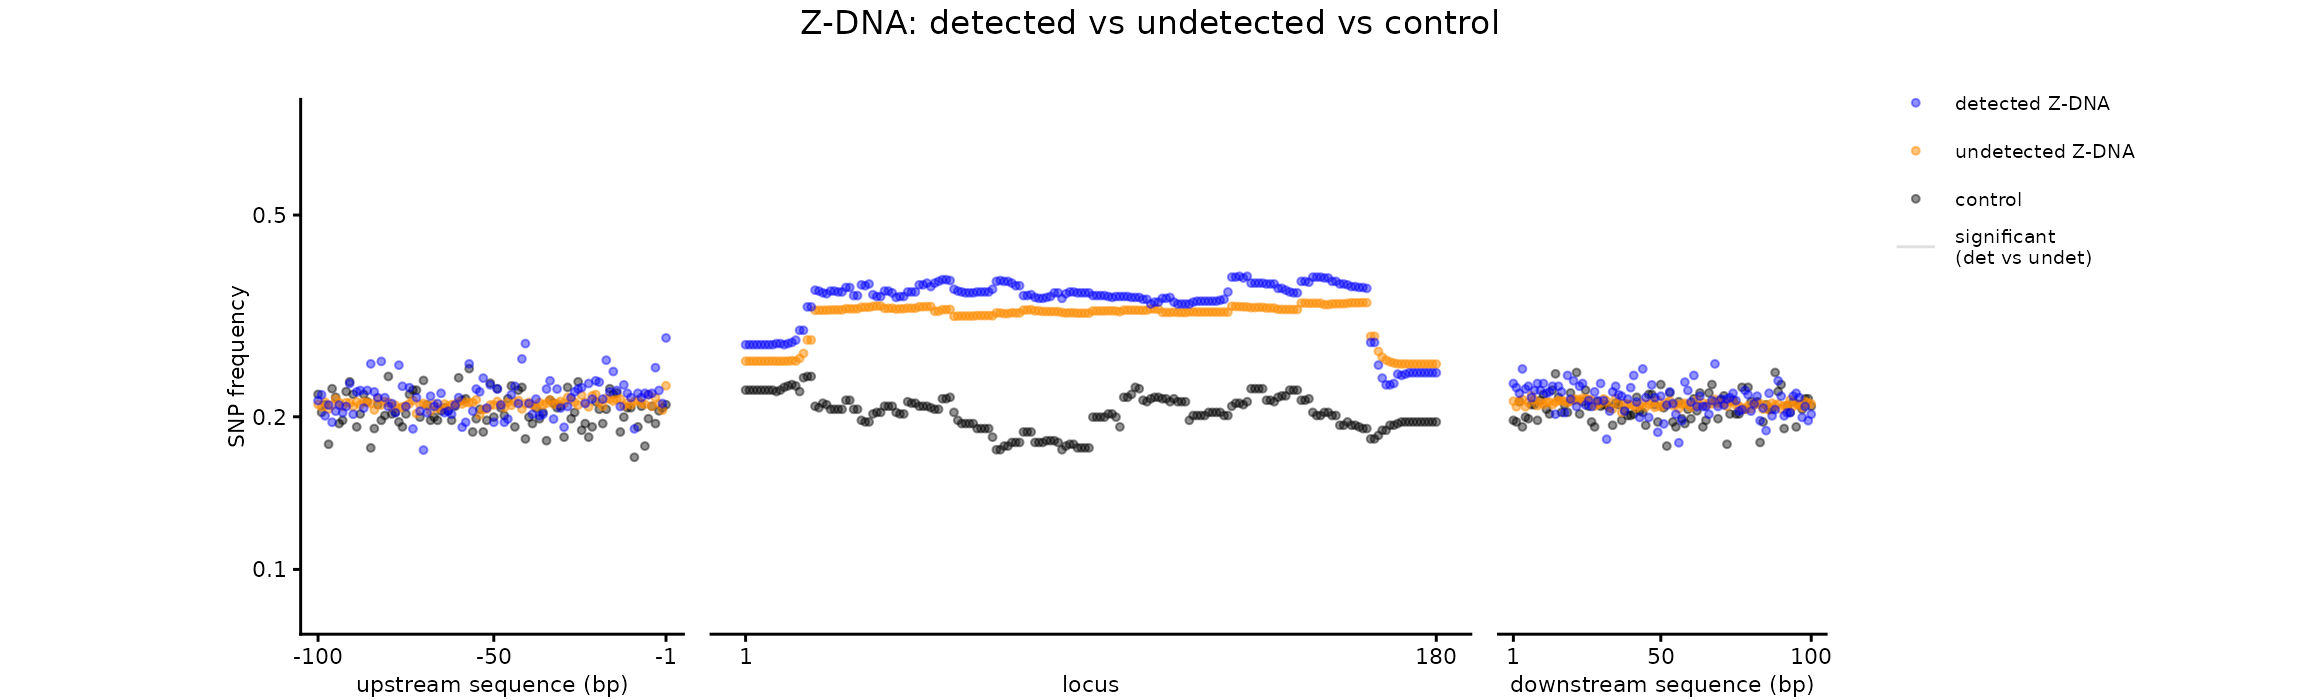

In [20]:
# R + ggplot 3-panel plot, detected / undetected / control
# Re-builds detected / control / undetected matrices and per-bin
# freqs, then plots via R + ggplot. Legend is placed outside the panels.
import os, subprocess
from pathlib import Path
from IPython.display import Image, display
import numpy as np, pandas as pd

WORKDIR = "/path/to/snp_af_analysis/results/zdna_notebook_detected_run"
os.chdir(WORKDIR)

MAX_FLANK  = 100
LOCUS_BINS = 180
scaledposLocus = [round(i, 4) for i in np.arange(1, LOCUS_BINS * 2, 2.0) / (LOCUS_BINS * 2)]

_counts = {k: int(v) for k, v in
           (line.split("\t") for line in Path("split_counts.txt").read_text().strip().splitlines())}
N_DET  = _counts["N_MOTIF"]
N_CTRL = _counts["N_CTRL"]
if "N_UNDET" not in _counts:
    raise RuntimeError(
        "N_UNDET not found in split_counts.txt -- run "
        "iwtomics_zdna/run_iwtomics_zdna_dvu.R first (it appends N_UNDET).")
N_UNDET = _counts["N_UNDET"]
print(f"N_DET={N_DET}  N_UNDET={N_UNDET}  N_CTRL={N_CTRL}")

def _build_matrices(intersect_path, n_loci):
    left  = np.zeros((n_loci, MAX_FLANK),  dtype=np.float32)
    locus = np.zeros((n_loci, LOCUS_BINS), dtype=np.float32)
    right = np.zeros((n_loci, MAX_FLANK),  dtype=np.float32)
    seen = set()
    with open(intersect_path) as fh:
        for line in fh:
            f = line.rstrip("\n").split("\t")
            if len(f) < 8: continue
            if len(f) >= 6 and f[5] == ".": continue
            lid, ps, pe, ptype, snp_start = int(f[3]), int(f[1]), int(f[2]), f[4], int(f[6])
            key = (lid, ptype, snp_start)
            if key in seen: continue
            seen.add(key)
            plen = pe - ps
            if ptype == "LeftFlank":
                idx = -(pe - snp_start) + MAX_FLANK
                if 0 <= idx < MAX_FLANK: left[lid, idx] += 1
            elif ptype == "RightFlank":
                idx = snp_start - ps
                if 0 <= idx < MAX_FLANK: right[lid, idx] += 1
            elif ptype == "Locus" and plen > 0:
                fs = (snp_start     - ps) / plen
                fe = (snp_start + 1 - ps) / plen
                for i, sp in enumerate(scaledposLocus):
                    if sp >= fs and sp < fe:
                        locus[lid, i] += 1
    return left, locus, right

print("building matrices (detected) ...")
d_l, d_c, d_r = _build_matrices("NCNRZDNA.gnomAD.intersect",          N_DET)
print("building matrices (control) ...")
c_l, c_c, c_r = _build_matrices("NCNRZDNA.gnomAD.shuffled.intersect", N_CTRL)
print("building matrices (undetected) ...")
u_l, u_c, u_r = _build_matrices("NCNRZDNA.gnomAD.undet.intersect",    N_UNDET)

def _freq(m, n): return m.sum(0) / n

pd.DataFrame({"LeftFlank":  _freq(d_l, N_DET),
              "ctrl_LeftFlank":  _freq(c_l, N_CTRL),
              "undet_LeftFlank": _freq(u_l, N_UNDET)}).to_csv("iwt_freq_dvu_LeftFlank.csv",  index=False)
pd.DataFrame({"RightFlank": _freq(d_r, N_DET),
              "ctrl_RightFlank": _freq(c_r, N_CTRL),
              "undet_RightFlank": _freq(u_r, N_UNDET)}).to_csv("iwt_freq_dvu_RightFlank.csv", index=False)
pd.DataFrame({"Locus": _freq(d_c, N_DET),
              "ctrl_Locus": _freq(c_c, N_CTRL),
              "undet_Locus": _freq(u_c, N_UNDET)}).to_csv("iwt_freq_dvu_Locus.csv", index=False)
print("wrote iwt_freq_dvu_{LeftFlank,RightFlank,Locus}.csv")

R_BIN = os.environ.get("R_BIN", "$R_BIN")

R_PLOT = r"""
suppressMessages({
  library(ggplot2); library(grid); library(gridExtra)
})

setwd("/path/to/snp_af_analysis/results/zdna_notebook_detected_run")

load("ZDNA_detected_vs_undetected_IWTomics_left_0.01.RData")
load("ZDNA_detected_vs_undetected_IWTomics_locus_0.01.RData")
load("ZDNA_detected_vs_undetected_IWTomics_right_0.01.RData")

freqL <- read.csv("iwt_freq_dvu_LeftFlank.csv")
freqC <- read.csv("iwt_freq_dvu_Locus.csv")
freqR <- read.csv("iwt_freq_dvu_RightFlank.csv")

LeftFlankDf  <- data.frame(Levels = seq(-100, -1, 1),
                           Det    = freqL$LeftFlank,
                           Und    = freqL$undet_LeftFlank,
                           Ctrl   = freqL$ctrl_LeftFlank,
                           Signif = adj_pvalue_curve_left$significant)
LocusDf      <- data.frame(Levels = seq_len(nrow(freqC)),
                           Det    = freqC$Locus,
                           Und    = freqC$undet_Locus,
                           Ctrl   = freqC$ctrl_Locus,
                           Signif = adj_pvalue_curve_locus$significant)
RightFlankDf <- data.frame(Levels = seq(1, 100, 1),
                           Det    = freqR$RightFlank,
                           Und    = freqR$undet_RightFlank,
                           Ctrl   = freqR$ctrl_RightFlank,
                           Signif = adj_pvalue_curve_right$significant)

allv <- c(LeftFlankDf$Det, LeftFlankDf$Und, LeftFlankDf$Ctrl,
          LocusDf$Det,     LocusDf$Und,     LocusDf$Ctrl,
          RightFlankDf$Det, RightFlankDf$Und, RightFlankDf$Ctrl)
allv <- allv[is.finite(allv) & allv > 0]
y_lo <- min(allv) * 0.5
y_hi <- max(allv) * 2

Y_BREAKS <- c(0.005, 0.01, 0.025, 0.05, 0.1, 0.2, 0.5, 1)
Y_BREAKS <- Y_BREAKS[Y_BREAKS >= y_lo & Y_BREAKS <= y_hi]

cols <- c(
  "detected Z-DNA"               = rgb(t(col2rgb("blue")),       alpha = 110, maxColorValue = 255),
  "undetected Z-DNA"             = rgb(t(col2rgb("darkorange")), alpha = 130, maxColorValue = 255),
  "control"                      = rgb(t(col2rgb("black")),      alpha = 110, maxColorValue = 255),
  "significant\n(det vs undet)"  = "grey88"
)

p1 <- ggplot(LeftFlankDf, aes(x = Levels)) +
  geom_vline(xintercept = LeftFlankDf$Levels[LeftFlankDf$Signif], col = "gray88") +
  geom_point(aes(y = Ctrl, col = "control"),          size = 1) +
  geom_point(aes(y = Und,  col = "undetected Z-DNA"), size = 1) +
  geom_point(aes(y = Det,  col = "detected Z-DNA"),   size = 1) +
  theme_classic() +
  theme(legend.position = "none",
        axis.title  = element_text(size = 8, family = "sans"),
        axis.text.x = element_text(size = 8, family = "sans"),
        axis.text.y = element_text(size = 8, family = "sans")) +
  labs(y = "SNP frequency", x = "upstream sequence (bp)") +
  scale_colour_manual(name = "", values = cols) +
  scale_x_continuous(breaks = c(-100, -50, -1), limits = c(-100, -1)) +
  theme(plot.margin = unit(c(20, 5, 1, 1), "pt")) +
  scale_y_continuous(trans = "log", limits = c(y_lo, y_hi), breaks = Y_BREAKS)

p2 <- ggplot(LocusDf, aes(x = Levels)) +
  geom_vline(xintercept = LocusDf$Levels[LocusDf$Signif], col = "gray88") +
  geom_point(aes(y = Ctrl, col = "control"),          size = 1) +
  geom_point(aes(y = Und,  col = "undetected Z-DNA"), size = 1) +
  geom_point(aes(y = Det,  col = "detected Z-DNA"),   size = 1) +
  theme_classic() +
  theme(legend.position = "none",
        axis.text.x  = element_text(size = 8, family = "sans"),
        axis.title.x = element_text(size = 8, family = "sans"),
        axis.title.y = element_blank(),
        axis.text.y  = element_blank(),
        axis.ticks.y = element_blank(),
        axis.line.y  = element_blank()) +
  labs(x = "locus") +
  scale_colour_manual(name = "", values = cols) +
  scale_x_continuous(breaks = c(1, nrow(LocusDf)), limits = c(1, nrow(LocusDf))) +
  theme(plot.margin = unit(c(20, 5, 1, 5), "pt")) +
  scale_y_continuous(trans = "log", limits = c(y_lo, y_hi), breaks = Y_BREAKS)

p3 <- ggplot(RightFlankDf, aes(x = Levels)) +
  geom_line(aes(x = 0, y = 0, colour = "significant\n(det vs undet)")) +
  geom_vline(xintercept = RightFlankDf$Levels[RightFlankDf$Signif], col = "gray88") +
  geom_point(aes(y = Ctrl, col = "control"),          size = 1) +
  geom_point(aes(y = Und,  col = "undetected Z-DNA"), size = 1) +
  geom_point(aes(y = Det,  col = "detected Z-DNA"),   size = 1) +
  theme_classic() +
  theme(axis.title.y = element_blank(),
        axis.text.y  = element_blank(),
        axis.ticks.y = element_blank(),
        axis.line.y  = element_blank(),
        axis.text.x  = element_text(size = 8, family = "sans"),
        axis.title.x = element_text(size = 8, family = "sans"),
        legend.text  = element_text(size = 7, family = "sans"),
        legend.position      = c(1.55, 0.90),
        legend.background     = element_rect(fill = "white", colour = NA)) +
  labs(x = "downstream sequence (bp)") +
  scale_colour_manual(name = "", values = cols,
                      breaks = c("detected Z-DNA", "undetected Z-DNA", "control",
                                 "significant\n(det vs undet)")) +
  scale_x_continuous(breaks = c(1, 50, 100), limits = c(1, 100)) +
  theme(plot.margin = unit(c(20, 90, 1, 5), "pt")) +
  scale_y_continuous(trans = "log", limits = c(y_lo, y_hi), breaks = Y_BREAKS) +
  guides(shape = guide_legend(order = 4))

g <- arrangeGrob(p1, p2, p3, ncol = 3,
                 widths = unit(c(60, 100, 75), c("mm", "mm", "mm")),
                 top = textGrob("Z-DNA: detected vs undetected vs control",
                                gp = gpar(fontsize = 12, family = "sans")))

ggsave("zdna_snp_frequency_notebook_dvu_iwtomics.pdf", g, width = 11.5, height = 3.5, dpi = 300, bg = "white")
ggsave("zdna_snp_frequency_notebook_dvu_iwtomics.png", g, width = 11.5, height = 3.5, dpi = 200, bg = "white")
cat("saved zdna_snp_frequency_notebook_dvu_iwtomics.{pdf,png}\n")
"""

Path("plot_zdna_dvu_iwtomics.R").write_text(R_PLOT)
print(f"plotting via {R_BIN} ...")
proc = subprocess.run([R_BIN, "--vanilla", "plot_zdna_dvu_iwtomics.R"],
                      capture_output=True, text=True)
print(proc.stdout)
if proc.returncode != 0:
    print("STDERR:\n", proc.stderr)
    raise RuntimeError(f"Rscript plot failed (code {proc.returncode})")

display(Image("zdna_snp_frequency_notebook_dvu_iwtomics.png"))